In [3]:
# 1. Cài đặt các thư viện và hệ thống FFmpeg để hỗ trợ file video (.MOV, .MP4)
!apt-get install ffmpeg -y -q
!pip install librosa soundfile matplotlib scipy pydub -q

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files

print("Hãy chọn và tải file video/âm thanh (.MOV, .MP4, .WAV, .MP3) của bạn lên Colab:")
uploaded = files.upload()

# Lấy tên file vừa tải lên
filename = list(uploaded.keys())[0]
print(f"\n--> Đã tải lên thành công tệp: {filename}")

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:6.1.1-3ubuntu5).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.
Hãy chọn và tải file video/âm thanh (.MOV, .MP4, .WAV, .MP3) của bạn lên Colab:


Saving IMG_2522.MOV to IMG_2522 (2).MOV

--> Đã tải lên thành công tệp: IMG_2522 (2).MOV


/tmp/ipykernel_2386/2252309958.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  x, Fs = librosa.load(filename, sr=None, mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


=== PHẦN A: THÔNG TIN METADATA TỪ FILE VIDEO ===
- Tên tệp đầu vào: IMG_2522 (2).MOV
- Tần số lấy mẫu (Fs): 44100 Hz
- Tần số Nyquist: 22050.0 Hz
- Số mẫu (Samples): 5744576
- Thời lượng âm thanh: 130.26 giây

=== PHẦN B: ĐẠI LƯỢNG MIỀN THỜI GIAN ===
- Peak: 0.9027
- RMS: 0.0467 (-26.62 dBFS)
- Năng lượng (Energy): 12520.0029


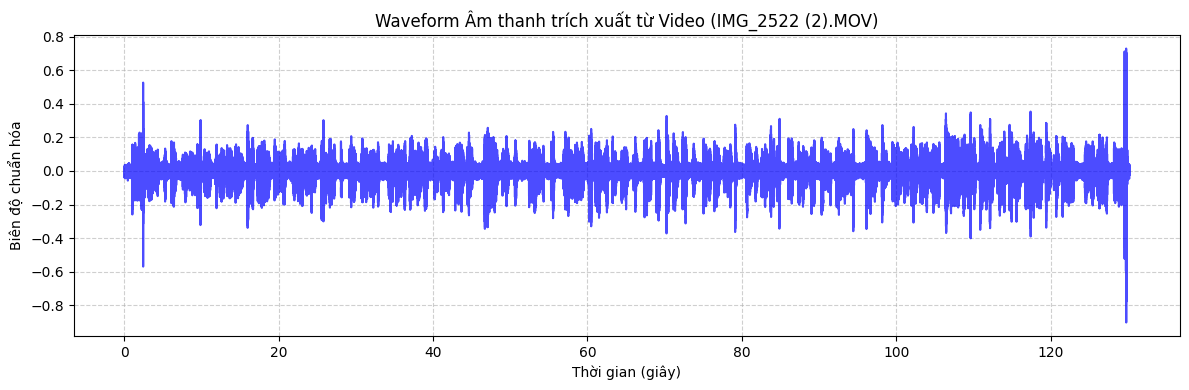

In [4]:
import librosa

# Đọc âm thanh từ file video .MOV
# librosa sẽ tự động tách luồng audio ra khỏi video, chuyển về mono và chuẩn hóa dải [-1.0, 1.0]
try:
    x, Fs = librosa.load(filename, sr=None, mono=True)
except Exception as e:
    print("Nếu librosa gặp khó khăn khi đọc trực tiếp file video, đang chuyển sang pydub để tách âm thanh...")
    from pydub import AudioSegment
    video_track = AudioSegment.from_file(filename)
    video_track.export("temp_extracted_audio.wav", format="wav")
    x, Fs = librosa.load("temp_extracted_audio.wav", sr=None, mono=True)

duration = len(x) / Fs

print("=== PHẦN A: THÔNG TIN METADATA TỪ FILE VIDEO ===")
print(f"- Tên tệp đầu vào: {filename}")
print(f"- Tần số lấy mẫu (Fs): {Fs} Hz")
print(f"- Tần số Nyquist: {Fs / 2} Hz")
print(f"- Số mẫu (Samples): {len(x)}")
print(f"- Thời lượng âm thanh: {duration:.2f} giây")

# B. Tính toán các đại lượng miền thời gian
peak_val = np.max(np.abs(x))
rms_val = np.sqrt(np.mean(x**2))
energy_val = np.sum(x**2)

print("\n=== PHẦN B: ĐẠI LƯỢNG MIỀN THỜI GIAN ===")
print(f"- Peak: {peak_val:.4f}")
print(f"- RMS: {rms_val:.4f} ({20*np.log10(rms_val + 1e-12):.2f} dBFS)")
print(f"- Năng lượng (Energy): {energy_val:.4f}")

# Vẽ Waveform
plt.figure(figsize=(12, 4))
time_axis = np.linspace(0, duration, len(x))
plt.plot(time_axis, x, color='b', alpha=0.7)
plt.title(f"Waveform Âm thanh trích xuất từ Video ({filename})", fontsize=12)
plt.xlabel("Thời gian (giây)")
plt.ylabel("Biên độ chuẩn hóa")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== PHẦN C: PHÂN TÍCH FFT ===
- Độ phân giải dải tần (Frequency bin spacing - Delta f): 0.673 Hz


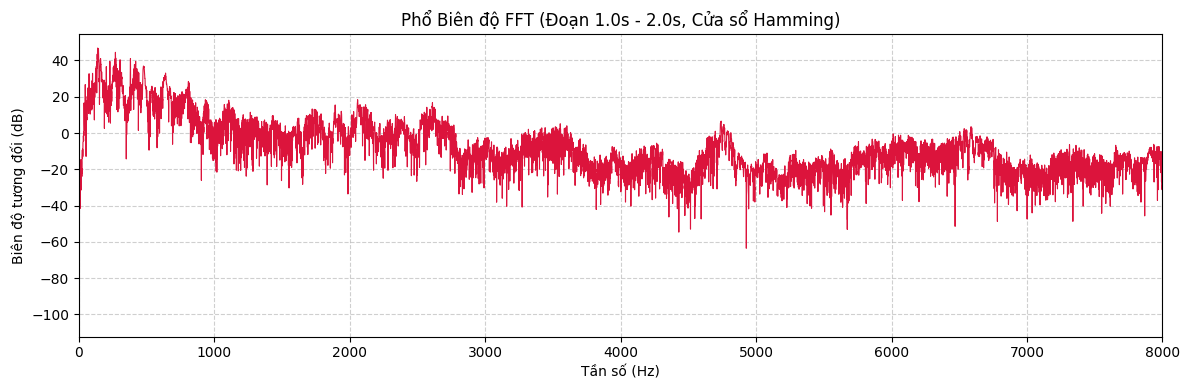

In [5]:
# C. Phân tích FFT trên một đoạn 1 giây (ví dụ từ giây thứ 1.0 đến 2.0)
start_sec = 1.0
end_sec = min(2.0, duration)

start_sample = int(start_sec * Fs)
end_sample = int(end_sec * Fs)
seg = x[start_sample:end_sample]

# Nhân cửa sổ Hamming
w = np.hamming(len(seg))
seg_windowed = seg * w

NFFT = 65536
X = np.fft.rfft(seg_windowed, n=NFFT)
f = np.fft.rfftfreq(NFFT, 1/Fs)
mag_db = 20 * np.log10(np.maximum(np.abs(X), 1e-12))
delta_f = Fs / NFFT

print("=== PHẦN C: PHÂN TÍCH FFT ===")
print(f"- Độ phân giải dải tần (Frequency bin spacing - Delta f): {delta_f:.3f} Hz")

# Vẽ Phổ FFT
plt.figure(figsize=(12, 4))
plt.plot(f, mag_db, color='crimson', linewidth=0.8)
plt.xlim(0, min(8000, Fs/2)) # Hiển thị dải tần đến 8000 Hz
plt.title(f"Phổ Biên độ FFT (Đoạn {start_sec}s - {end_sec}s, Cửa sổ Hamming)", fontsize=12)
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ tương đối (dB)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Cảnh báo: File dài 130.3s. Để tránh tràn RAM, chỉ phân tích STFT cho 30s đầu tiên.
Cấu hình STFT: Fs = 44100 Hz, Frame = 1102 mẫu, Hop = 441 mẫu, NFFT = 2048


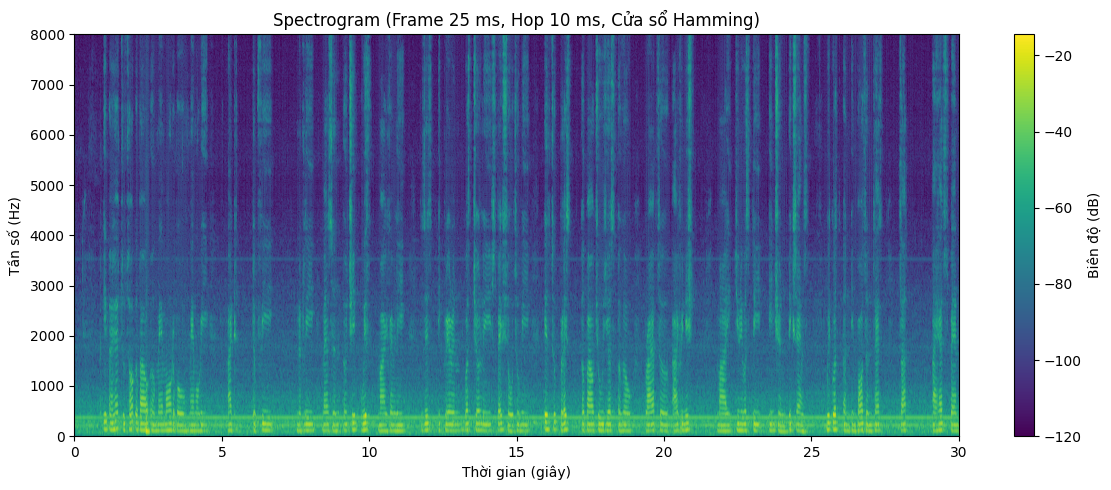

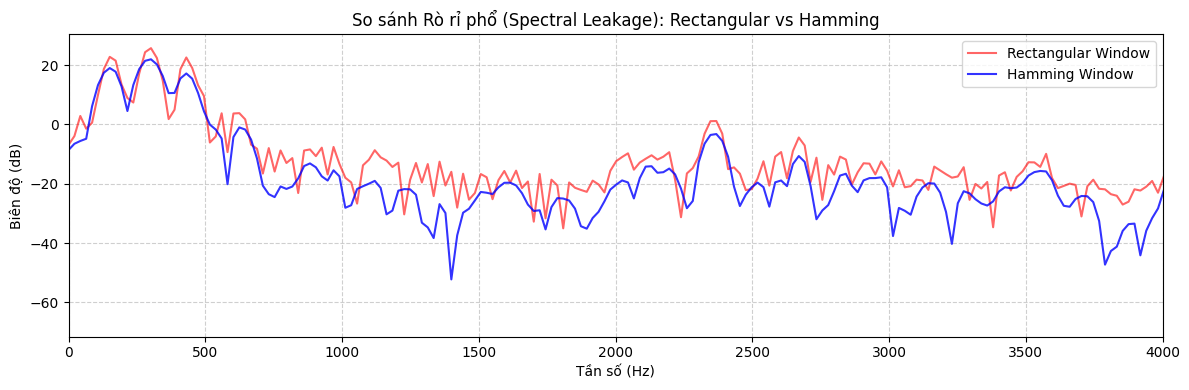

In [6]:
# CELL 4 (BẢN TỐI ƯU & CHỐNG LỖI RAM)
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# 1. Giới hạn độ dài để tránh tràn RAM nếu file .MOV quá dài (Ví dụ: Lấy tối đa 30s đầu)
max_seconds = 30
if duration > max_seconds:
    print(f"Cảnh báo: File dài {duration:.1f}s. Để tránh tràn RAM, chỉ phân tích STFT cho {max_seconds}s đầu tiên.")
    x_stft = x[:int(max_seconds * Fs)]
else:
    x_stft = x

# 2. Tính toán tham số Frame, Hop và NFFT an toàn
frame_len = round(0.025 * Fs)  # 25 ms
hop_len = round(0.010 * Fs)    # 10 ms

# Tự động chọn nfft là lũy thừa của 2 và lớn hơn frame_len
nfft = 2**int(np.ceil(np.log2(frame_len)))
if nfft < 2048:
    nfft = 2048

print(f"Cấu hình STFT: Fs = {Fs} Hz, Frame = {frame_len} mẫu, Hop = {hop_len} mẫu, NFFT = {nfft}")

# 3. Tính STFT
f_stft, t_stft, Zxx = signal.stft(x_stft, fs=Fs, window='hamming',
                                  nperseg=frame_len, noverlap=frame_len - hop_len,
                                  nfft=nfft)
S_db = 20 * np.log10(np.maximum(np.abs(Zxx), 1e-6))

# 4. Vẽ Spectrogram
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_stft, f_stft, S_db, shading='gouraud', cmap='viridis')
plt.colorbar(label='Biên độ (dB)')
plt.ylim(0, min(8000, Fs/2)) # Giới hạn hiển thị đến 8 kHz
plt.title("Spectrogram (Frame 25 ms, Hop 10 ms, Cửa sổ Hamming)", fontsize=12)
plt.xlabel("Thời gian (giây)")
plt.ylabel("Tần số (Hz)")
plt.tight_layout()
plt.show()

# 5. So sánh Cửa sổ Rectangular vs Hamming trên 1 frame
start_sample = int(1.0 * Fs) if len(x) > int(1.0 * Fs) else 0
frame_data = x[start_sample : start_sample + frame_len]
rect_win = np.ones(len(frame_data))
hamm_win = np.hamming(len(frame_data))

X_rect = np.fft.rfft(frame_data * rect_win, n=nfft)
X_hamm = np.fft.rfft(frame_data * hamm_win, n=nfft)
f_win = np.fft.rfftfreq(nfft, 1/Fs)

plt.figure(figsize=(12, 4))
plt.plot(f_win, 20*np.log10(np.maximum(np.abs(X_rect), 1e-6)), label='Rectangular Window', color='red', alpha=0.6)
plt.plot(f_win, 20*np.log10(np.maximum(np.abs(X_hamm), 1e-6)), label='Hamming Window', color='blue', alpha=0.8)
plt.xlim(0, min(4000, Fs/2))
plt.title("So sánh Rò rỉ phổ (Spectral Leakage): Rectangular vs Hamming", fontsize=12)
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ (dB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== PHẦN F: THIẾT KẾ BỘ LỌC FIR ===
- Số taps (bậc bộ lọc + 1): 201
- Tần số cắt (Cutoff): 2000.0 Hz
- Độ trễ nhóm (Group delay): 100 mẫu (~ 2.27 ms)


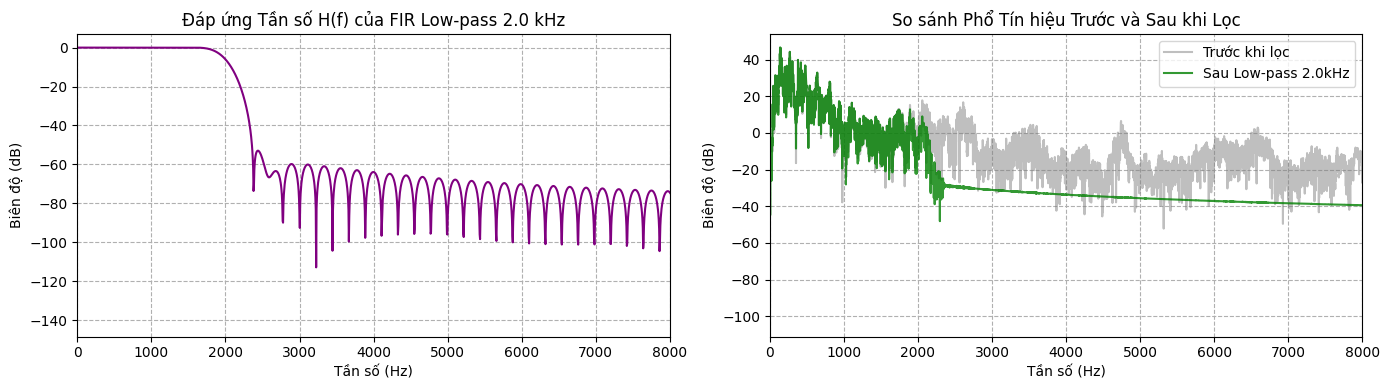


--> Đã xuất file audio sau khi lọc: 'audio_filtered_lpf.wav'


In [7]:
# CELL 5: LỌC SỐ FIR LOW-PASS
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# 1. Khai báo thông số bộ lọc FIR
numtaps = 201
cutoff_hz = 2000.0  # Tần số cắt 2 kHz

# Kiểm tra nếu cutoff_hz lớn hơn tần số Nyquist (Fs / 2)
if cutoff_hz >= Fs / 2:
    cutoff_hz = (Fs / 2) * 0.8
    print(f"Cảnh báo: Cutoff được điều chỉnh về {cutoff_hz} Hz để nhỏ hơn Nyquist ({Fs/2} Hz).")

# Thiết kế bộ lọc FIR dùng cửa sổ Hamming
b = signal.firwin(numtaps, cutoff=cutoff_hz, fs=Fs, window='hamming')

# 2. Áp dụng bộ lọc lên tín hiệu âm thanh
y = signal.lfilter(b, [1.0], x)

# 3. Tính đáp ứng tần số H(f)
w_res, H_res = signal.freqz(b, [1.0], worN=4096, fs=Fs)

# Tính độ trễ nhóm (Group delay)
group_delay = (numtaps - 1) / 2
delay_ms = (group_delay / Fs) * 1000

print("=== PHẦN F: THIẾT KẾ BỘ LỌC FIR ===")
print(f"- Số taps (bậc bộ lọc + 1): {numtaps}")
print(f"- Tần số cắt (Cutoff): {cutoff_hz} Hz")
print(f"- Độ trễ nhóm (Group delay): {group_delay:.0f} mẫu (~ {delay_ms:.2f} ms)")

# 4. Trực quan hóa kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Đồ thị Đáp ứng tần số H(f)
axes[0].plot(w_res, 20 * np.log10(np.abs(H_res) + 1e-12), color='purple')
axes[0].set_title(f"Đáp ứng Tần số H(f) của FIR Low-pass {cutoff_hz/1000:.1f} kHz")
axes[0].set_xlabel("Tần số (Hz)")
axes[0].set_ylabel("Biên độ (dB)")
axes[0].set_xlim(0, min(8000, Fs/2))
axes[0].grid(True, linestyle='--')

# Đồ thị Phổ trước và sau khi lọc (Lấy đoạn 1s đại diện)
start_sample = int(1.0 * Fs) if len(x) > int(1.0 * Fs) else 0
end_sample = min(start_sample + int(Fs), len(x))
seg_orig = x[start_sample:end_sample]
seg_filt = y[start_sample:end_sample]

w_seg = np.hamming(len(seg_orig))
NFFT = 32768

X_orig = np.fft.rfft(seg_orig * w_seg, n=NFFT)
X_filt = np.fft.rfft(seg_filt * w_seg, n=NFFT)
f_axis = np.fft.rfftfreq(NFFT, 1/Fs)

axes[1].plot(f_axis, 20*np.log10(np.maximum(np.abs(X_orig), 1e-12)), label='Trước khi lọc', alpha=0.5, color='gray')
axes[1].plot(f_axis, 20*np.log10(np.maximum(np.abs(X_filt), 1e-12)), label=f'Sau Low-pass {cutoff_hz/1000:.1f}kHz', color='green', alpha=0.8)
axes[1].set_xlim(0, min(8000, Fs/2))
axes[1].set_title("So sánh Phổ Tín hiệu Trước và Sau khi Lọc")
axes[1].set_xlabel("Tần số (Hz)")
axes[1].set_ylabel("Biên độ (dB)")
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# 5. Lưu tệp audio sau khi lọc để tải/nghe thử
audio_filtered_pcm16 = (y / np.max(np.abs(y)) * 32767).astype(np.int16)
wavfile.write("audio_filtered_lpf.wav", Fs, audio_filtered_pcm16)
print("\n--> Đã xuất file audio sau khi lọc: 'audio_filtered_lpf.wav'")

=== PHẦN G: LƯỢNG TỬ HÓA VÀ SNR DO ĐƯỢC ===
- Bit depth B =  4 bit/mẫu  =>  SNR đo được = 3.11 dB
- Bit depth B =  6 bit/mẫu  =>  SNR đo được = 13.20 dB
- Bit depth B =  8 bit/mẫu  =>  SNR đo được = 25.46 dB
- Bit depth B = 12 bit/mẫu  =>  SNR đo được = 49.61 dB
- Bit depth B = 16 bit/mẫu  =>  SNR đo được = 72.39 dB


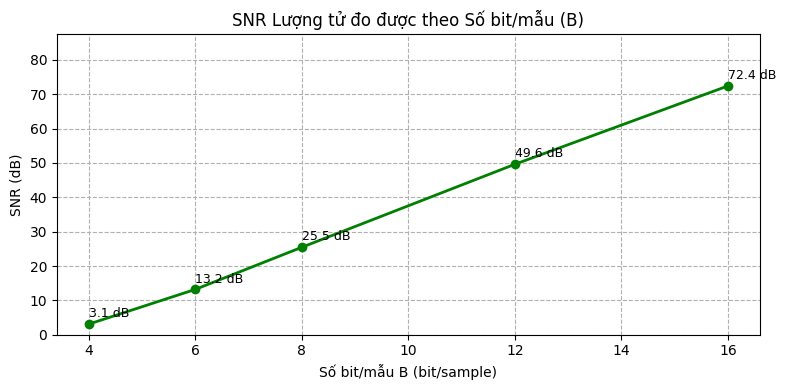


=== BÁO CÁO TỐC ĐỘ BIT & DUNG LƯỢNG LÝ THUYẾT ===
- Tần số lấy mẫu (Fs): 44100 Hz
- Thời lượng tệp audio: 130.26 giây
- Bitrate PCM 16-bit Mono gốc: 705.6 kbps
- Kích thước tệp PCM 16-bit lý thuyết: 10.96 MB
- Dung lượng ước tính nếu nén MP3 256 kbps: 3.98 MB (Tỉ lệ nén ~ 2.76:1)
- Dung lượng ước tính nếu nén MP3 128 kbps: 1.99 MB (Tỉ lệ nén ~ 5.51:1)


In [8]:
# CELL 6: LƯỢNG TỬ HÓA, TÍNH SNR VÀ NÉN AUDIO
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa các hàm Lượng tử hóa và tính SNR
def quantize(signal_in, B):
    """ Lượng tử hóa tín hiệu về B-bit """
    qmax = 2**(B - 1) - 1
    xq = np.round(np.clip(signal_in, -1.0, 1.0) * qmax) / qmax
    return xq

def calculate_snr(orig, quant):
    """ Tính SNR giữa tín hiệu gốc và tín hiệu lượng tử """
    e = quant - orig
    signal_power = np.sum(orig**2)
    noise_power = np.sum(e**2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

# Để tính toán nhanh và tiết kiệm RAM, lấy tối đa 30 giây dữ liệu để thử nghiệm lượng tử
max_sec_quant = 30
x_quant_eval = x[:int(max_sec_quant * Fs)]

print("=== PHẦN G: LƯỢNG TỬ HÓA VÀ SNR DO ĐƯỢC ===")
bit_depths = [4, 6, 8, 12, 16]
snr_results = []

for B in bit_depths:
    xq = quantize(x_quant_eval, B)
    snr_val = calculate_snr(x_quant_eval, xq)
    snr_results.append(snr_val)
    print(f"- Bit depth B = {B:2d} bit/mẫu  =>  SNR đo được = {snr_val:.2f} dB")

# 2. Vẽ đồ thị biểu diễn mối quan hệ giữa B và SNR
plt.figure(figsize=(8, 4))
plt.plot(bit_depths, snr_results, marker='o', color='green', linestyle='-', linewidth=2)
for i, txt in enumerate(snr_results):
    plt.annotate(f"{txt:.1f} dB", (bit_depths[i], snr_results[i] + 2), fontsize=9)

plt.title("SNR Lượng tử đo được theo Số bit/mẫu (B)", fontsize=12)
plt.xlabel("Số bit/mẫu B (bit/sample)")
plt.ylabel("SNR (dB)")
plt.grid(True, linestyle='--')
plt.ylim(0, max(snr_results) + 15)
plt.tight_layout()
plt.show()

# 3. Tính toán Tốc độ bit (Bitrate) và Dung lượng PCM lý thuyết
channels = 1  # Đã chuyển về mono ở Cell 2
pcm_bitrate_bps = Fs * 16 * channels  # Chuẩn PCM 16-bit
pcm_bitrate_kbps = pcm_bitrate_bps / 1000
file_size_pcm_mb = (pcm_bitrate_bps * duration) / (8 * 1024 * 1024)

print("\n=== BÁO CÁO TỐC ĐỘ BIT & DUNG LƯỢNG LÝ THUYẾT ===")
print(f"- Tần số lấy mẫu (Fs): {Fs} Hz")
print(f"- Thời lượng tệp audio: {duration:.2f} giây")
print(f"- Bitrate PCM 16-bit Mono gốc: {pcm_bitrate_kbps:.1f} kbps")
print(f"- Kích thước tệp PCM 16-bit lý thuyết: {file_size_pcm_mb:.2f} MB")

# So sánh ví dụ với các chuẩn nén MP3
mp3_256_size = (256 * 1000 * duration) / (8 * 1024 * 1024)
mp3_128_size = (128 * 1000 * duration) / (8 * 1024 * 1024)

print(f"- Dung lượng ước tính nếu nén MP3 256 kbps: {mp3_256_size:.2f} MB (Tỉ lệ nén ~ {file_size_pcm_mb/mp3_256_size:.2f}:1)")
print(f"- Dung lượng ước tính nếu nén MP3 128 kbps: {mp3_128_size:.2f} MB (Tỉ lệ nén ~ {file_size_pcm_mb/mp3_128_size:.2f}:1)")

=== BẢNG SO SÁNH DUNG LƯỢNG THỰC TẾ VÀ LÝ THUYẾT ===


,Loại tệp / Cấu hình,Dung lượng (MB),Tỉ lệ so với PCM lý thuyết
0,PCM 16-bit Mono (Lý thuyết),10.96,100% (Gốc)
1,Tệp gốc đã tải lên (.MOV),87.31,796.8%
2,Tệp WAV sau lọc (audio_filtered_lpf.wav),10.96,100.0%
3,Ước tính MP3 (128 kbps),1.99,18.1%
4,Ước tính MP3 (256 kbps),3.98,36.3%


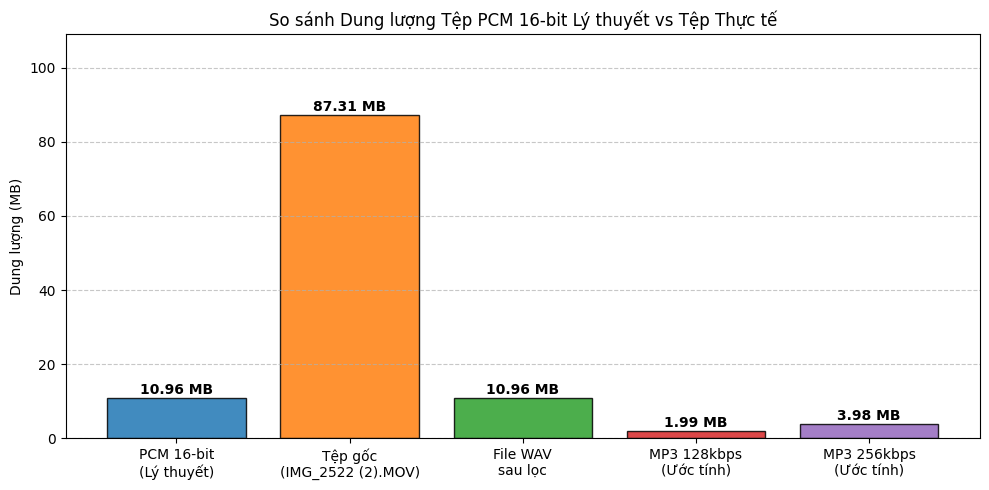

In [9]:
# CELL 7: SO SÁNH DUNG LƯỢNG PCM LÝ THUYẾT VÀ TỆP THỰC TẾ
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tính dung lượng lý thuyết (Bytes & MB)
pcm_16bit_bytes_theory = (Fs * 16 * 1 * duration) / 8  # Mono 16-bit
pcm_16bit_mb_theory = pcm_16bit_bytes_theory / (1024 * 1024)

# 2. Lấy dung lượng thực tế của tệp đầu vào (.MOV/.MP4/etc)
size_input_bytes = os.path.getsize(filename)
size_input_mb = size_input_bytes / (1024 * 1024)

# 3. Lấy dung lượng thực tế của tệp WAV đã xuất sau khi lọc (audio_filtered_lpf.wav)
filtered_filename = "audio_filtered_lpf.wav"
if os.path.exists(filtered_filename):
    size_filtered_bytes = os.path.getsize(filtered_filename)
    size_filtered_mb = size_filtered_bytes / (1024 * 1024)
else:
    size_filtered_mb = 0

# 4. Tạo bảng so sánh chi tiết
data = {
    "Loại tệp / Cấu hình": [
        "PCM 16-bit Mono (Lý thuyết)",
        f"Tệp gốc đã tải lên ({os.path.splitext(filename)[1].upper()})",
        "Tệp WAV sau lọc (audio_filtered_lpf.wav)",
        "Ước tính MP3 (128 kbps)",
        "Ước tính MP3 (256 kbps)"
    ],
    "Dung lượng (MB)": [
        round(pcm_16bit_mb_theory, 2),
        round(size_input_mb, 2),
        round(size_filtered_mb, 2),
        round((128 * 1000 * duration) / (8 * 1024 * 1024), 2),
        round((256 * 1000 * duration) / (8 * 1024 * 1024), 2)
    ],
    "Tỉ lệ so với PCM lý thuyết": [
        "100% (Gốc)",
        f"{size_input_mb / pcm_16bit_mb_theory * 100:.1f}%",
        f"{size_filtered_mb / pcm_16bit_mb_theory * 100:.1f}%",
        f"{((128 * 1000 * duration) / (8 * 1024 * 1024)) / pcm_16bit_mb_theory * 100:.1f}%",
        f"{((256 * 1000 * duration) / (8 * 1024 * 1024)) / pcm_16bit_mb_theory * 100:.1f}%"
    ]
}

df_compare = pd.DataFrame(data)

print("=== BẢNG SO SÁNH DUNG LƯỢNG THỰC TẾ VÀ LÝ THUYẾT ===")
display(df_compare)

# 5. Vẽ đồ thị so sánh (Bar Chart)
labels = ['PCM 16-bit\n(Lý thuyết)', f'Tệp gốc\n({filename})', 'File WAV\nsau lọc', 'MP3 128kbps\n(Ước tính)', 'MP3 256kbps\n(Ước tính)']
sizes = [
    pcm_16bit_mb_theory,
    size_input_mb,
    size_filtered_mb,
    (128 * 1000 * duration) / (8 * 1024 * 1024),
    (256 * 1000 * duration) / (8 * 1024 * 1024)
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, sizes, color=colors, alpha=0.85, edgecolor='black')

# Hiển thị giá trị dung lượng trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')

plt.title("So sánh Dung lượng Tệp PCM 16-bit Lý thuyết vs Tệp Thực tế", fontsize=12)
plt.ylabel("Dung lượng (MB)")
plt.ylim(0, max(sizes) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()